> Projeto Desenvolve <br>
Programação Intermediária com Python <br>
Profa. Camila Laranjeira (mila@projetodesenvolve.com.br) <br>

# 3.11 - Data Model

## Exercícios

#### Q1. `dataclass`
Exercício adaptado de [codechalleng.es/bites/154/](https://codechalleng.es/bites/154/) e [codechalleng.es/bites/320/](https://codechalleng.es/bites/320/).

Neste desafio, você deve escrever uma `dataclass` chamada `Bite` que gerencia 3 atributos: `number`, `title` e `level`. Seus tipos são:
* `number` - `int`, 
* `title` - `str`, 
* `level` -  classe `Enum` chamada `BiteLevel` com os atributos `Beginner`, `Intermediate`, `Advanced`. 

Exemplo de dado: `{'number': 154, 'title': 'Escreva uma dataclass', 'level': BiteLevel.Intermediate}`

As características dessa classe são:
* O atributo`level` tem um valor padrão `BiteLevel.Beginner`
* Uma coleção de objetos `Bite` tem que ser ordenável somente pelo atributo `number`
* Implemente o método especial `__str__` para imprimir o Bite na forma `f'{number} - {title} ({level})'`

Teste sua classe executando o seguinte código:
```python
bites = []
bites.append(Bite(154, 'Escreva uma dataclass', 'Intermediate'))
bites.append(Bite(1, 'Some n valores'))
bites.append(Bite(37, 'Reescreva um loop com recursão', 'Intermediate'))

for b in bites.sort(): print(b)
# Ordem esperada na saída:
# 1 - Some n valores (Beginner)
# 37 - Reescreva um loop com recursão (Intermediate)
# 154 - Escreva uma dataclass (Intermediate)
```

In [1]:
from dataclasses import dataclass, field
from enum import Enum


class BiteLevel(Enum):
    Beginner = "Beginner"
    Intermediate = "Intermediate"
    Advanced = "Advanced"


@dataclass(order=True)
class Bite:
    number: int
    title: str = field(compare=False)
    level: BiteLevel = field(default=BiteLevel.Beginner, compare=False)

    def __post_init__(self):
        if isinstance(self.level, str):
            self.level = BiteLevel[self.level]

    def __str__(self):
        return f"{self.number} - {self.title} ({self.level.value})"


# Teste

bites = []
bites.append(Bite(154, "Escreva uma dataclass", "Intermediate"))
bites.append(Bite(1, "Some n valores"))
bites.append(Bite(37, "Reescreva um loop com recursão", "Intermediate"))

bites.sort()

for b in bites:
    print(b)

1 - Some n valores (Beginner)
37 - Reescreva um loop com recursão (Intermediate)
154 - Escreva uma dataclass (Intermediate)


#### Q2. `Pydantic`
> Adaptada desse [tutorial de Pydantic](https://github.com/adonath/scipy-2023-pydantic-tutorial/tree/main) criado por [Axel Donath](https://github.com/adonath) e [Nick Langellier](https://github.com/nlangellier).

Observe a seguinte lista de observações da previsão do tempo em Murmansk, Russia.
```python
data_samples = [
    {
        "date": "2023-05-20",
        "temperature": 62.2,
        "isCelsius": False,
        "airQualityIndex": "24",
        "sunriseTime": "01:26",
        "sunsetTime": "00:00",
    },
    {
        "date": "2023-05-21",
        "temperature": "64.4",
        "isCelsius": "not true",
        "airQualityIndex": 23,
        "sunriseTime": "01:10",
        "sunsetTime": "00:16",
    },
    {
        "date": "2023-05-22",
        "temperature": 14.4,
        "airQualityIndex": 21,
    },
]
```

Escreva um script que calcule e imprima a temperatura média (em Celsius) em Murmansk para as datas fornecidas. Em seu script, você deve incluir um modelo Pydantic que registre com sucesso todos os elementos dados. Note que:

* Algumas amostras estão faltando dados. Você deve decidir quando o atributo pode ter um valor padrão ou quando definí-lo como opcional (`typing.Optional`). 
* Você precisará implementar pelo menos um validador de campo para transformar atributos. Dica: teste primeiro quais vão falhar :)



In [6]:
from pydantic import BaseModel
from typing import Optional
from datetime import date

data_samples = [
    {
        "date": "2023-05-20",
        "temperature": 62.2,
        "isCelsius": False,
        "airQualityIndex": "24",
        "sunriseTime": "01:26",
        "sunsetTime": "00:00",
    },
    {
        "date": "2023-05-21",
        "temperature": "64.4",
        "isCelsius": "not true",
        "airQualityIndex": 23,
        "sunriseTime": "01:10",
        "sunsetTime": "00:16",
    },
    {
        "date": "2023-05-22",
        "temperature": 14.4,
        "airQualityIndex": 21,
    },
]


class Weather(BaseModel):
    date: date
    temperature: float
    isCelsius: bool = True
    airQualityIndex: int
    sunriseTime: Optional[str] = None
    sunsetTime: Optional[str] = None

    def __init__(self, **data):
        # Converte "not true" para False
        if isinstance(data.get("isCelsius"), str):
            data["isCelsius"] = data["isCelsius"].lower() == "true"

        super().__init__(**data)

        # Se estiver em Fahrenheit, converte para Celsius
        if not self.isCelsius:
            self.temperature = (self.temperature - 32) * 5 / 9


# Cria os objetos
weather_data = [Weather(**item) for item in data_samples]

# Calcula a média
media = sum(item.temperature for item in weather_data) / len(weather_data)

print(f"Temperatura média: {media:.2f} °C")

Temperatura média: 16.39 °C


#### Q3
> Adaptada desse [tutorial de Pydantic](https://github.com/adonath/scipy-2023-pydantic-tutorial/tree/main) criado por [Axel Donath](https://github.com/adonath) e [Nick Langellier](https://github.com/nlangellier).

Na célula a seguir, coletamos dados reais de uma das principais APIs de previsão do tempo, [open-meteo](https://open-meteo.com/en/docs). Não se preocupe em entender esse código, o mais importante é entender o resultado que ele retorna, ilustrado a seguir para uma coleta da temperatura dos últimos 15 dias em Itabira -MG. Caso deseje alterar a cidade de coleta, basta alimentar a latitude e longitude desejada, como nas opções a seguir.
* Itabira: `'latitude': -19.656655787605846, 'longitude': -43.228922960534476`
* Bom Despacho: `'latitude': -19.726308457732443, 'longitude': -45.27462803349767`

```python
{
  "latitude": -19.5,
  "longitude": -43.375,
  "generationtime_ms": 0.01800060272216797,
  "utc_offset_seconds": 0,
  "timezone": "GMT",
  "timezone_abbreviation": "GMT",
  "elevation": 2.0,
  "hourly_units": {
    "time": "iso8601",
    "temperature_2m": "\u00b0C"
  },
  "hourly": {
    "time": [
      "2024-07-19T00:00",
      "2024-07-19T01:00",
      "2024-07-19T02:00",
      ...
    ],
    "temperature_2m": [
      21.9,
      20.9,
      20.0,
      ... 
    ]
  }
}
```

Você deve escrever um modelo Pydantic `OpenMeteo` que receba diretamente a resposta dessa API, através do comando:
```python
dados = OpenMeteo(**response)
``` 

Para comportar a estrutura hierárquica desse dicionário (é um dicionário com alguns dicionários internos), você deve criar uma classe Pydantic para cada dicionário interno (`HourlyUnits` e `Hourly`), com seus respectivos atributos. Essas classes serão atributos da classe principal `OpenMeteo`, que terá também os outros atributos da resposta (`latitude`, `longitude`, etc.).



In [ ]:
import requests, json

url = 'https://api.open-meteo.com/v1/forecast'
lat, long = -19.656655787605846, -43.228922960534476
params = {'latitude': lat, 'longitude': long, 'elevation': 2,
          'hourly': 'temperature_2m', 'forecast_days': 15}
response = requests.get(url, params=params).json()
print(json.dumps(response, indent=2))

In [9]:
from pydantic import BaseModel
from typing import List
import requests
import json


class HourlyUnits(BaseModel):
    time: str
    temperature_2m: str


class Hourly(BaseModel):
    time: List[str]
    temperature_2m: List[float]


class OpenMeteo(BaseModel):
    latitude: float
    longitude: float
    generationtime_ms: float
    utc_offset_seconds: int
    timezone: str
    timezone_abbreviation: str
    elevation: float
    hourly_units: HourlyUnits
    hourly: Hourly


# Coleta dos dados
url = "https://api.open-meteo.com/v1/forecast"

lat, long = -19.656655787605846, -43.228922960534476

params = {
    "latitude": lat,
    "longitude": long,
    "elevation": 2,
    "hourly": "temperature_2m",
    "forecast_days": 15,
}

response = requests.get(url, params=params).json()

# Cria o objeto Pydantic
dados = OpenMeteo(**response)

# Testes
print(dados)
print()
print("Latitude:", dados.latitude)
print("Longitude:", dados.longitude)
print("Timezone:", dados.timezone)
print("Primeira temperatura:", dados.hourly.temperature_2m[0])
print("Primeiro horário:", dados.hourly.time[0])

latitude=-19.648506 longitude=-43.253723 generationtime_ms=0.03504753112792969 utc_offset_seconds=0 timezone='GMT' timezone_abbreviation='GMT' elevation=2.0 hourly_units=HourlyUnits(time='iso8601', temperature_2m='°C') hourly=Hourly(time=['2026-07-16T00:00', '2026-07-16T01:00', '2026-07-16T02:00', '2026-07-16T03:00', '2026-07-16T04:00', '2026-07-16T05:00', '2026-07-16T06:00', '2026-07-16T07:00', '2026-07-16T08:00', '2026-07-16T09:00', '2026-07-16T10:00', '2026-07-16T11:00', '2026-07-16T12:00', '2026-07-16T13:00', '2026-07-16T14:00', '2026-07-16T15:00', '2026-07-16T16:00', '2026-07-16T17:00', '2026-07-16T18:00', '2026-07-16T19:00', '2026-07-16T20:00', '2026-07-16T21:00', '2026-07-16T22:00', '2026-07-16T23:00', '2026-07-17T00:00', '2026-07-17T01:00', '2026-07-17T02:00', '2026-07-17T03:00', '2026-07-17T04:00', '2026-07-17T05:00', '2026-07-17T06:00', '2026-07-17T07:00', '2026-07-17T08:00', '2026-07-17T09:00', '2026-07-17T10:00', '2026-07-17T11:00', '2026-07-17T12:00', '2026-07-17T13:00', '

#### Q4. 

Com os dados carregados na questão anterior plote um gráfico de linha, com a biblioteca de sua preferência, onde o eixo `x` são os timestamps (data e hora) e o eixo `y` é a temperatura medida.

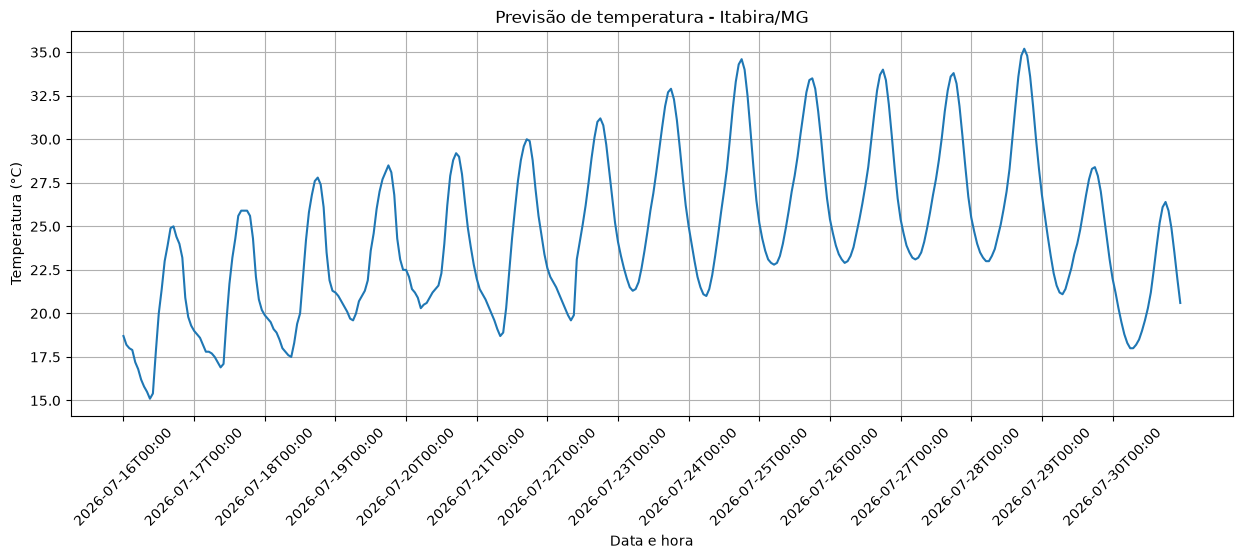

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(dados.hourly.time, dados.hourly.temperature_2m)

plt.title("Previsão de temperatura - Itabira/MG")
plt.xlabel("Data e hora")
plt.ylabel("Temperatura (°C)")

# Mostra apenas alguns horários no eixo X
plt.xticks(dados.hourly.time[::24], rotation=45)

plt.grid()

plt.show()